# 3. Height-height correlations 

In [1]:
import numpy as np
import pandas as pd
import os

from surface_functions import compute_height_height_correlations

In [5]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.4}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 1, "KPZ": 0.96}} # anomalous scaling, only for columnar noise
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

## Dataframe computations

In [3]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        heightheight_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            heightheight = np.asarray(compute_height_height_correlations(phases), dtype=float)

            heightheight_list.append(heightheight)

        # Avoid chained-assignment issues
        df = df.copy()
        df["heightheight"] = heightheight_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE HEIGHT-HEIGHT CORRELATION PER (K, L, T) ##
        # group by K, L, T and compute mean height-height correlation for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            heightheight_arrays = [np.asarray(r, dtype=float) for r in group["heightheight"]]
            mean_heightheight = np.mean(np.stack(heightheight_arrays, axis=0), axis=0)
            
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_heightheight": mean_heightheight,
                }
            )

        print("Seeds (index):", df.index.tolist())
        # print("Number of simulations:", M)
        print("Columns:", df.columns.tolist())

## TimeDep – Delta 0
Seeds (index): ['L500_K1_seed78375102', 'L500_K1_seed48022158', 'L500_K1_seed21517135', 'L500_K1_seed73450932', 'L500_K1_seed5701930', 'L500_K0.01_seed66323775', 'L500_K1_seed66955334', 'L500_K0.01_seed51276577', 'L500_K1_seed66776927', 'L500_K0.01_seed39155229', 'L500_K1_seed10688739', 'L500_K0.01_seed74911657', 'L500_K1_seed14995512', 'L500_K0.01_seed92687884', 'L500_K1_seed11013623', 'L500_K0.01_seed77570756', 'L500_K1_seed26524819', 'L500_K0.01_seed87634771', 'L500_K1_seed61884301', 'L500_K0.01_seed87439695', 'L500_K1_seed70493549', 'L500_K0.01_seed46007736', 'L500_K1_seed16437593', 'L500_K0.01_seed55248971', 'L500_K1_seed13595782', 'L500_K0.01_seed18901207', 'L500_K1_seed41894445', 'L500_K0.01_seed90297636', 'L500_K1_seed7367704', 'L500_K0.01_seed24097069', 'L500_K1_seed78608552', 'L500_K0.01_seed73001616', 'L500_K1_seed46449722', 'L500_K0.01_seed31008285', 'L500_K1_seed22480058', 'L500_K1_seed4733608', 'L500_K0.01_seed39831824', 'L500_K1_seed92871047', 'L500_

In [4]:
# === add this after the loops ===
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_heightheight"] = new_avg["mean_heightheight"]

avg_df.to_pickle(avg_df_path)

In [5]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2,mean_heightheight
avg_id,,,,,,,,,,,
TimeDep_delta0_L500_K0.01_T20000_M500,TimeDep,0.000000,0,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.09932794776024303, 0.12445710235930987...","[0.0, 0.09937158963203278, 0.12451669747551469...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L125_K1.0_T20000_M1000,TimeDep,0.000000,0,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1000,20000,"[0.0, 0.06206535180620217, 0.06962088956407118...","[0.0, 0.06224447417192954, 0.06987538331690908...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L250_K1.0_T20000_M500,TimeDep,0.000000,0,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.06185445817599045, 0.0696865309816036,...","[0.0, 0.061951592706644056, 0.0698286189854493...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L500_K1.0_T20000_M500,TimeDep,0.000000,0,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.062281209851627814, 0.0703404523305143...","[0.0, 0.062330873676472595, 0.0704074790636151...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L1000_K1.0_T2000_M500,TimeDep,0.000000,0,1.00,1000,"[0.0, 1.000005000025, 1.6000080000400003, 2.56...",500,2000,"[0.0, 0.062289693394964187, 0.0704964066887407...","[0.0, 0.06231310748464172, 0.070528464896139, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L500_K0.01_T20000_M500,TimeDep,1.373401,atan5,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.10014740577543957, 0.1261770083222738,...","[0.0, 0.10019634453950993, 0.12623155432190383...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L125_K1.0_T20000_M1000,TimeDep,1.373401,atan5,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1000,20000,"[0.0, 0.08497581574082771, 0.10016716020392952...","[0.0, 0.085169740061077, 0.10039858844247401, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L250_K1.0_T20000_M500,TimeDep,1.373401,atan5,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.08525314007445625, 0.10040309251048023...","[0.0, 0.08534060165610576, 0.10051558946041181...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L500_K1.0_T20000_M500,TimeDep,1.373401,atan5,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.08538735713321526, 0.10092130285727816...","[0.0, 0.08543379532608593, 0.10098882300685771...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


## Inspection of the computed quantities

In [8]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

In [9]:
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

L = 500
T = 20000

In [10]:
markerdict = {500: "o", 250: "x", 125: "^", 1000: "s"}

In [11]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND)
tx = {"TimeDep": {"EW": 1/30, "KPZ": 1/3}, "Columnar": {"EW": 1/200, "KPZ": 1/10}}

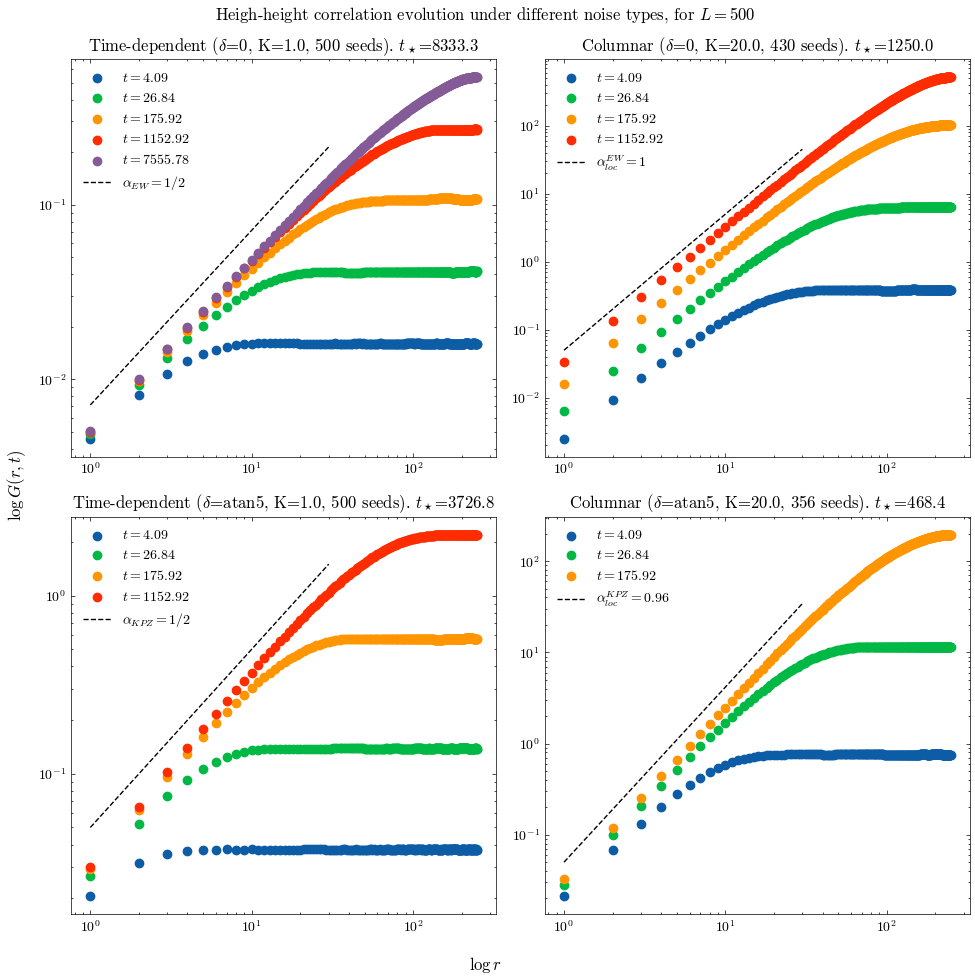

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("Heigh-height correlation evolution under different noise types, for $L=$" + str(L))

fig.supxlabel(r"$\log r$")
fig.supylabel(r"$\log G(r,t)$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
):

    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["L"] == L)
            & (avg_df["T"] == T)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == 1) | (avg_df["K"] == 20))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]            
            mean_heightheight = row["mean_heightheight"]
            L = row["L"]
            K = row["K"]
            M = row["M"]

            t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])

            for ti in range(mean_heightheight.shape[0])[::4]:

                if t[ti] > 0 and t[ti] < t_cross:

                    rlen = mean_heightheight.shape[1] # we plot up to half of this since the system is periodic
                    rrange = np.array(range(rlen))
                    ax[j,i].scatter(rrange[:int(rlen/2)], mean_heightheight[ti,:int(rlen/2)], label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L])

            ax[j,i].set_title(typelabel+ r" ($\delta$="+f"{deltaname}, K={K}, {M} seeds). " + r"$t_\star$=" + f"{np.round(t_cross,1)}")

        ax[j,i].set_xscale('log')
        ax[j,i].set_yscale('log')

# scaling as r^(2\alpha) = r^1 for alpha = 1/2 (EW/KPZ)
ax[0,0].loglog(rrange[1:int(rlen/16)], rrange[1:int(rlen/16)]**(2*alpha_loc_dict["TimeDep"]["EW"])/140, label=r"$\alpha_{EW}=1/2$", linestyle="--", color="k")
ax[1,0].loglog(rrange[1:int(rlen/16)], rrange[1:int(rlen/16)]**(2*alpha_loc_dict["TimeDep"]["KPZ"])/20, label=r"$\alpha_{KPZ}=1/2$", linestyle="--", color="k")

# scaling as r^(2\alpha) = r^2 for alpha_loc approx 1 (EW/KPZ)
ax[0,1].loglog(rrange[1:int(rlen/16)], rrange[1:int(rlen/16)]**(2*alpha_loc_dict["Columnar"]["EW"])/20, label=r"$\alpha_{loc}^{EW}=1$", linestyle="--", color="k")
ax[1,1].loglog(rrange[1:int(rlen/16)], rrange[1:int(rlen/16)]**(2*alpha_loc_dict["Columnar"]["KPZ"])/20, label=r"$\alpha_{loc}^{KPZ}=0.96$", linestyle="--", color="k")

ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.tight_layout()
plt.show()

### Family-Vicsek collapse of the height-height correlations

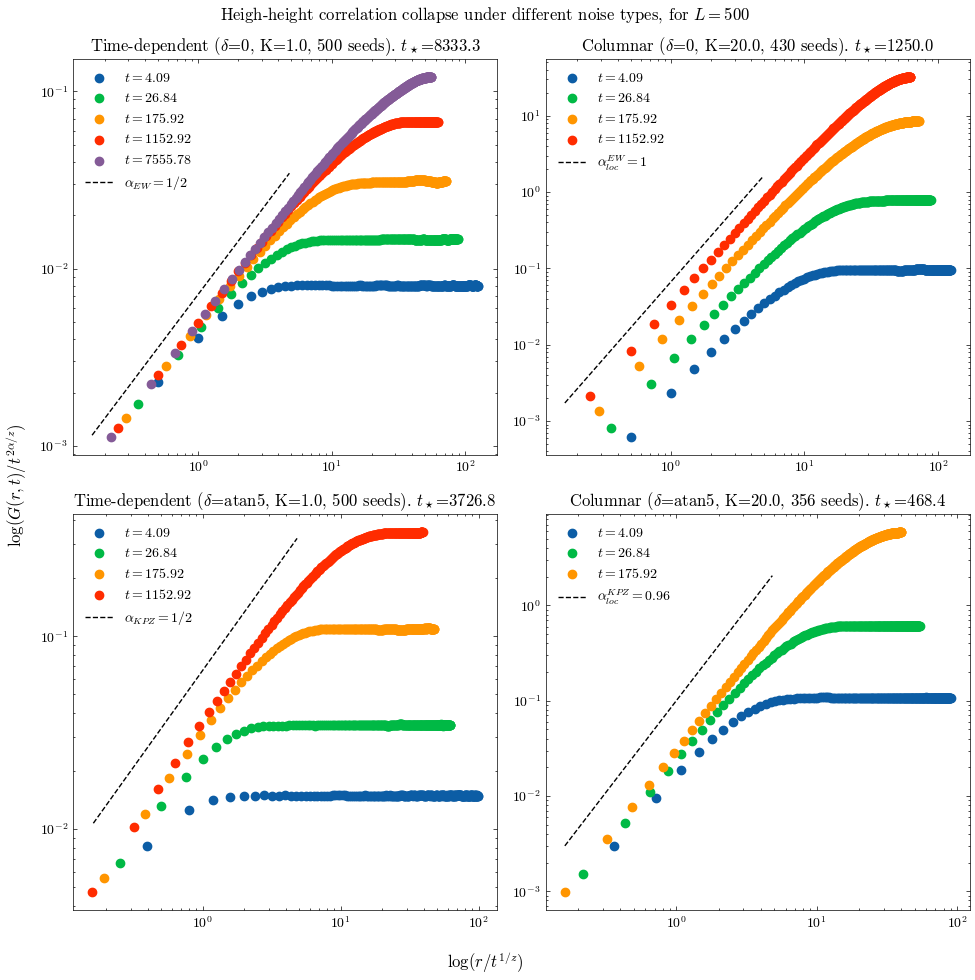

In [28]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("Heigh-height correlation collapse under different noise types, for $L=$" + str(L))

fig.supxlabel(r"$\log (r/ t^{1/z})$")
fig.supylabel(r"$\log (G(r,t)/ t^{2\alpha/z})$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
):

    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["L"] == L)
            & (avg_df["T"] == T)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == 1) | (avg_df["K"] == 20))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]
            mean_heightheight = row["mean_heightheight"]
            L = row["L"]
            K = row["K"]
            M = row["M"]

            t_cross = tx[typenoise][delta_to_label[deltaname]] * L**(z_dict[typenoise][delta_to_label[deltaname]])
            
            for ti in range(mean_heightheight.shape[0])[::4]:

                if t[ti] > 0 and t[ti] < t_cross:

                    rlen = mean_heightheight.shape[1] # we plot up to half of this since the system is periodic
                    rrange = np.array(range(rlen))

                    # Collapse variables
                    rt1z = rrange[:int(rlen/2)] / ti**(1/z_dict[typenoise][delta_to_label[deltaname]])
                    Gt2az = mean_heightheight[ti,:int(rlen/2)] / ti**(2*alpha_loc_dict[typenoise][delta_to_label[deltaname]]/z_dict[typenoise][delta_to_label[deltaname]])

                    ax[j,i].scatter(rt1z, Gt2az, label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L])
                
            ax[j,i].set_title(typelabel+ r" ($\delta$="+f"{deltaname}, K={K}, {M} seeds). " + r"$t_\star$=" + f"{np.round(t_cross,1)}")

            ax[j,i].set_yscale('log')
            ax[j,i].set_xscale('log')

# scaling as r^(2\alpha) = r^1 for alpha = 1/2 (EW/KPZ)
ax[0,0].loglog(rt1z[1:int(rlen/16)], rt1z[1:int(rlen/16)]**(2*alpha_loc_dict["TimeDep"]["EW"]) /140, label=r"$\alpha_{EW}=1/2$", linestyle="--", color="k")
ax[1,0].loglog(rt1z[1:int(rlen/16)], rt1z[1:int(rlen/16)]**(2*alpha_loc_dict["TimeDep"]["KPZ"])/15, label=r"$\alpha_{KPZ}=1/2$", linestyle="--", color="k")

# scaling as r^(2\alpha) = r^2 for alpha_loc approx 1 (EW/KPZ)
ax[0,1].loglog(rt1z[1:int(rlen/16)], rt1z[1:int(rlen/16)]**(2*alpha_loc_dict["Columnar"]["EW"])/15, label=r"$\alpha_{loc}^{EW}=1$", linestyle="--", color="k")
ax[1,1].loglog(rt1z[1:int(rlen/16)], rt1z[1:int(rlen/16)]**(2*alpha_loc_dict["Columnar"]["KPZ"])/10, label=r"$\alpha_{loc}^{KPZ}=0.96$", linestyle="--", color="k")

ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.tight_layout()
plt.show()

NOT SURE IF THE COLLAPSE VARIABLE SHOULD HAVE ALPHA OR ALPHA_LOC